# 04. Spectrogram of a single speaker

Plots the waveform and log-mel spectrogram for one speaker, in both audio
conditions. Intended for a figure illustrating the data rather than for
analysis. Set `SPEAKER` below and run.

In [1]:
SPEAKER = None      # e.g. "01_P"; leave as None to pick the first depressed speaker

import os
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display

import common
from common import CORPUS, load_metadata

interview_df, label_of, gender_of, interview_folds = load_metadata()

if SPEAKER is None:
    SPEAKER = sorted(sid for sid, y in label_of.items() if y == 1)[0]

row = interview_df[interview_df["speaker_id"] == SPEAKER].iloc[0]
full_path = row["full_recording_path"]

print(f"Speaker  : {SPEAKER}")
print(f"Condition: {'depressed' if label_of[SPEAKER] else 'control'}")
print(f"Gender   : {gender_of[SPEAKER]}   Age: {row['age']}")
print(f"Recording: {full_path}")

Speaker  : 01_P
Condition: depressed
Gender   : M   Age: 58
Recording: ./Androids-Corpus/Androids-Corpus/Interview-Task/audio/PT/01_PM58_2.wav


In [2]:
# Locate the participant-only clips for this speaker
clip_dir = f"{CORPUS}/Interview-Task/audio_clip"
clip_paths = []
for condition in sorted(os.listdir(clip_dir)):
    if condition == ".DS_Store":
        continue
    sub = os.path.join(clip_dir, condition)
    if not os.path.isdir(sub):
        continue
    for clip in sorted(os.listdir(sub)):
        if not clip.endswith(".wav"):
            continue
        uid, mid, *_ = clip.replace(".wav", "").split("_")
        if f"{uid}_{mid[0]}" == SPEAKER:
            clip_paths.append(os.path.join(sub, clip))

print(f"{len(clip_paths)} participant turns found")

7 participant turns found


In [3]:
SR = 16000   # resample; the corpus is 44.1 kHz, which is more detail than needed here

y_full, _ = librosa.load(full_path, sr=SR)
y_part = np.concatenate([librosa.load(p, sr=SR)[0] for p in clip_paths])

print(f"Full recording : {len(y_full)/SR:.1f} s")
print(f"Participant only: {len(y_part)/SR:.1f} s")

m:\anaconda\envs\androids\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Full recording : 279.6 s
Participant only: 254.3 s


## Waveform and spectrogram, both conditions

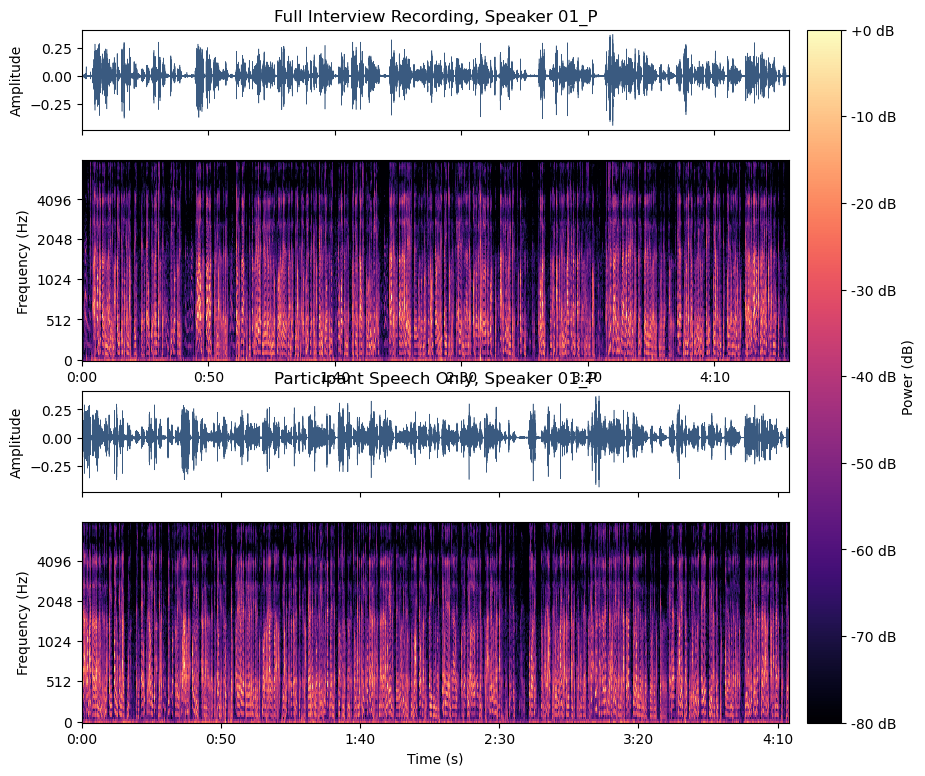

Saved figures/spectrogram_01_P.png


In [4]:
def plot_condition(y, sr, title, axes):
    ax_wave, ax_spec = axes

    t = np.arange(len(y)) / sr
    ax_wave.plot(t, y, linewidth=0.4, color="#3a5a80")
    ax_wave.set_xlim(0, t[-1])
    ax_wave.set_ylabel("Amplitude")
    ax_wave.set_title(title)
    ax_wave.set_xticklabels([])

    S = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=1024, hop_length=256, n_mels=128)
    S_db = librosa.power_to_db(S, ref=np.max)
    img = librosa.display.specshow(S_db, sr=sr, hop_length=256,
                                   x_axis="time", y_axis="mel", ax=ax_spec, cmap="magma")
    ax_spec.set_ylabel("Frequency (Hz)")
    ax_spec.set_xlabel("Time (s)")
    return img


fig, axes = plt.subplots(4, 1, figsize=(11, 9),
                         gridspec_kw={"height_ratios": [1, 2, 1, 2]})

plot_condition(y_full, SR, f"Full Interview Recording, Speaker {SPEAKER}", axes[0:2])
img = plot_condition(y_part, SR, f"Participant Speech Only, Speaker {SPEAKER}", axes[2:4])

fig.colorbar(img, ax=axes, format="%+2.0f dB", label="Power (dB)", pad=0.02)
plt.savefig(f"figures/spectrogram_{SPEAKER}.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved figures/spectrogram_{SPEAKER}.png")

## A single segment

The models operate on fixed-length segments rather than whole recordings. At the
shortest length tested, one segment covers roughly one second of speech.

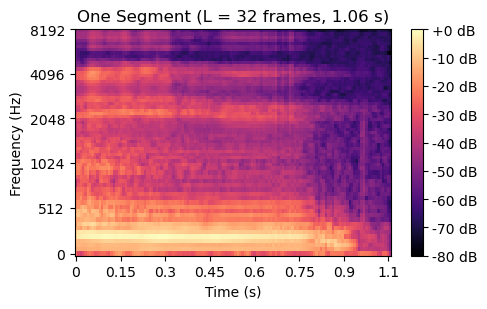

In [5]:
SEG_SECONDS = 32 * 0.033      # L = 32 frames at 33 ms per frame
START = 10.0                  # seconds into the participant-only audio

seg = y_part[int(START * SR):int((START + SEG_SECONDS) * SR)]

fig, ax = plt.subplots(figsize=(5, 3.2))
S = librosa.feature.melspectrogram(y=seg, sr=SR, n_fft=512, hop_length=128, n_mels=64)
img = librosa.display.specshow(librosa.power_to_db(S, ref=np.max), sr=SR, hop_length=128,
                               x_axis="time", y_axis="mel", ax=ax, cmap="magma")
ax.set_title(f"One Segment (L = 32 frames, {SEG_SECONDS:.2f} s)")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Frequency (Hz)")
fig.colorbar(img, ax=ax, format="%+2.0f dB")
plt.tight_layout()
plt.savefig(f"figures/segment_example_{SPEAKER}.png", dpi=200, bbox_inches="tight")
plt.show()

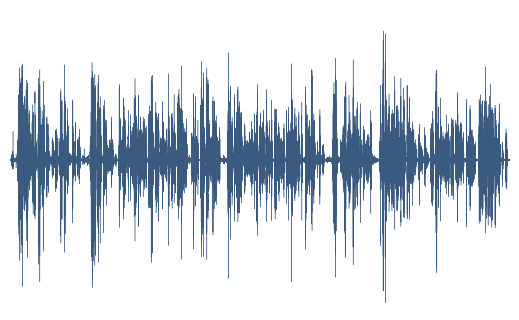

Saved figures/waveform_01_P.png (279.6 s)


In [ ]:
SPEAKER = None      # e.g. "01_P"; leave as None to pick the first depressed speaker
SR = 16000

import numpy as np
import matplotlib.pyplot as plt
import librosa
from common import load_metadata

interview_df, label_of, gender_of, _ = load_metadata()
if SPEAKER is None:
    SPEAKER = sorted(sid for sid, y in label_of.items() if y == 1)[0]

path = interview_df.loc[interview_df["speaker_id"] == SPEAKER, "full_recording_path"].iloc[0]
y, _ = librosa.load(path, sr=SR)

fig = plt.figure(figsize=(5, 3), dpi=100)
ax = fig.add_axes([0, 0, 1, 1])
ax.plot(y, linewidth=0.3, color="#3a5a80")
ax.set_xlim(0, len(y))
ax.set_ylim(-np.abs(y).max() * 1.05, np.abs(y).max() * 1.05)
ax.axis("off")

out = f"figures/waveform_{SPEAKER}.png"
fig.savefig(out, dpi=200, pad_inches=0, transparent=True)
plt.show()
print("Saved", out, f"({len(y)/SR:.1f} s)")